# Notebook lane/02 — Classical CV Baseline (PDF §4.1)

Pipeline: **ROI crop → HSV-S channel + grayscale → Canny → probabilistic Hough lines → angle-histogram features + slope statistics → SVM (4-class)**.

The 4 classes are `left / right / straight / stop`. Stop training samples are synthesized by zeroing the lane-ROI of randomly-selected TuSimple frames, simulating "no lane is visible".

Justifications (paper-ready):
- **HSV-S channel** is added to grayscale because lane markings (white/yellow) are saturation-low in white but saturation-high relative to surrounding asphalt — empirically improves recall.
- **ROI** = lower 60% of frame: removes sky and irrelevant horizon clutter.
- **Hough lines** are mandatory here (per the PDF's "optional shape detection" — for lane direction it is the natural shape descriptor).
- **Feature vector** is compact (≤30 numbers) → fast linear SVM.

In [1]:
import os, random, json, pickle, time
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED); random.seed(SEED)
import numpy as np
np.random.seed(SEED)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
with open(ROOT / "artifacts" / "lane_split.json") as f: SPLIT = json.load(f)
with open(ROOT / "artifacts" / "lane_tusimple_index.pkl", "rb") as f: IDX = pickle.load(f)
df = IDX["df"]
print(f"TuSimple records: {len(df)}")

TuSimple records: 3626


## 1. Pre-processing pipeline visualization on one frame

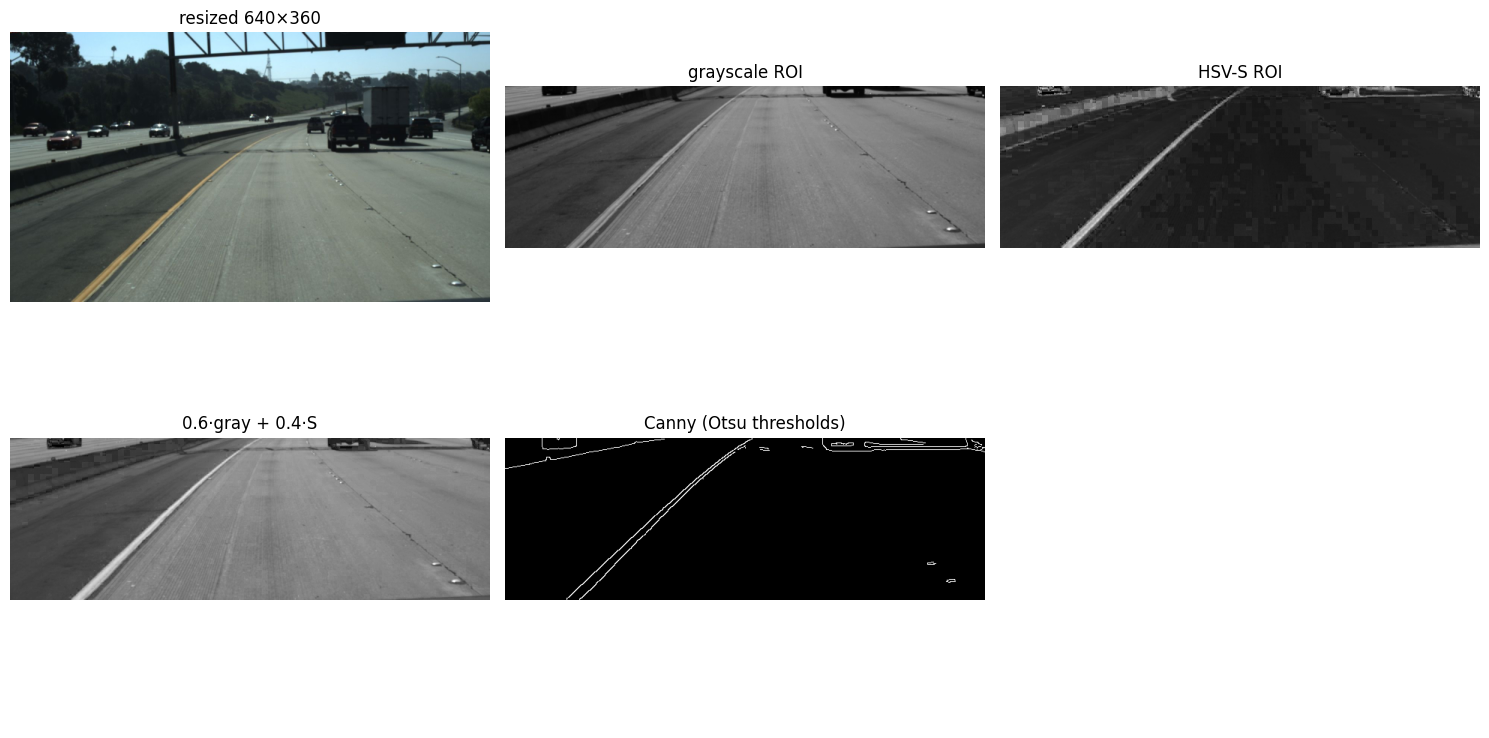

In [2]:
IMG_W, IMG_H = 1280, 720
PROC_W, PROC_H = 640, 360            # downsampled for classical speed
ROI_FRAC_TOP   = 0.40                # top 40% is sky/horizon; we drop it

def preprocess(rgb):
    # 1. resize for speed
    small = cv2.resize(rgb, (PROC_W, PROC_H))
    # 2. take ROI: lower 60%
    top = int(PROC_H * ROI_FRAC_TOP)
    roi = small[top:, :, :]
    # 3. HSV-S channel + grayscale fused
    hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)
    sat = hsv[..., 1]
    gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)
    fused = cv2.addWeighted(gray, 0.6, sat, 0.4, 0)
    # 4. Gaussian blur + Canny
    blur = cv2.GaussianBlur(fused, (5, 5), 0)
    med = float(np.median(blur))
    lo = max(0, int(0.66 * med)); hi = min(255, int(1.33 * med))
    edges = cv2.Canny(blur, lo, hi)
    return dict(small=small, roi=roi, gray=gray, sat=sat, fused=fused, edges=edges, top=top)

# Demo on one frame
demo = df.sample(1, random_state=SEED).iloc[0]
demo_img = cv2.cvtColor(cv2.imread(str(ROOT / demo["frame_path"])), cv2.COLOR_BGR2RGB)
P = preprocess(demo_img)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(P["small"]); axes[0, 0].set_title("resized 640×360"); axes[0, 0].axis("off")
axes[0, 1].imshow(P["gray"], cmap="gray"); axes[0, 1].set_title("grayscale ROI"); axes[0, 1].axis("off")
axes[0, 2].imshow(P["sat"], cmap="gray");  axes[0, 2].set_title("HSV-S ROI");    axes[0, 2].axis("off")
axes[1, 0].imshow(P["fused"], cmap="gray"); axes[1, 0].set_title("0.6·gray + 0.4·S"); axes[1, 0].axis("off")
axes[1, 1].imshow(P["edges"], cmap="gray"); axes[1, 1].set_title("Canny (Otsu thresholds)"); axes[1, 1].axis("off")
axes[1, 2].axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane02_preprocess_demo.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Hough lines → cluster into left vs right

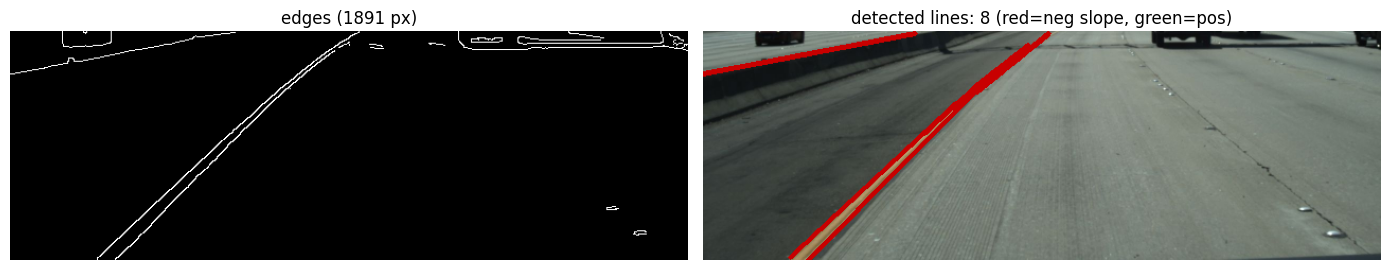

feature vector: [ 8.00000e+00 -8.29000e-01  2.54000e-01  2.59745e+02  8.58130e+01
  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
  0.00000e+00  0.00000e+00  0.00000e+00  8.75000e-01  0.00000e+00
  1.25000e-01  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00
  0.00000e+00  0.00000e+00  8.00000e+00  8.00000e+00  0.00000e+00
  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]


In [3]:
def hough_features(edges):
    # 30-D feature vector summarizing detected lines
    H_roi = edges.shape[0]; W_roi = edges.shape[1]
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=40,
                            minLineLength=30, maxLineGap=15)
    if lines is None:
        # no lines at all -> all-zero features (treated as stop signal)
        feat = np.zeros(30, dtype=np.float32)
        feat[28] = 0  # n_lines
        return feat, []
    items = []
    for x1, y1, x2, y2 in lines[:, 0]:
        dx, dy = x2 - x1, y2 - y1
        if dx == 0: continue
        slope = dy / dx
        ang = np.degrees(np.arctan2(dy, dx))
        if abs(slope) < 0.15: continue   # drop near-horizontals (likely shadows / cars)
        items.append((x1, y1, x2, y2, slope, ang))
    if not items:
        feat = np.zeros(30, dtype=np.float32); feat[28] = 0; return feat, items

    arr = np.array([(it[4], it[5]) for it in items])
    left  = [it for it in items if it[4] < 0]
    right = [it for it in items if it[4] > 0]

    def stat(lst, slope_idx=4):
        if not lst:
            return (0.0, 0.0, 0.0, 0.0, 0.0)
        sls = np.array([l[slope_idx] for l in lst])
        ints = np.array([(l[1] - l[slope_idx]*l[0]) for l in lst])  # y-intercept
        return (float(len(lst)), float(sls.mean()), float(sls.std() or 0),
                float(ints.mean()), float(ints.std() or 0))
    f_left  = stat(left)
    f_right = stat(right)
    # angle histogram (12 bins from -90 to 90)
    angs = arr[:, 1]
    hist, _ = np.histogram(angs, bins=12, range=(-90, 90))
    hist = hist.astype(np.float32) / max(1, hist.sum())
    feat = np.concatenate([list(f_left), list(f_right), hist,
                            [len(items), len(left), len(right)]]).astype(np.float32)
    if feat.size < 30:
        feat = np.concatenate([feat, np.zeros(30 - feat.size, dtype=np.float32)])
    return feat[:30], items

# Demo on the same image
feat, items = hough_features(P["edges"])
view = P["roi"].copy()
for x1, y1, x2, y2, sl, ang in items:
    color = (0, 200, 0) if sl > 0 else (200, 0, 0)
    cv2.line(view, (x1, y1), (x2, y2), color, 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(P["edges"], cmap="gray"); axes[0].set_title(f"edges ({P['edges'].sum()/255:.0f} px)"); axes[0].axis("off")
axes[1].imshow(view); axes[1].set_title(f"detected lines: {len(items)} (red=neg slope, green=pos)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane02_hough_demo.png", dpi=120, bbox_inches="tight")
plt.show()
print("feature vector:", feat.round(3))

## 3. Build training / val / test feature matrices

We use the TuSimple split saved by Notebook 01. For each frame, we compute the 30-D Hough feature vector and stack into X arrays. **Stop class** is synthesized: we take 10% of every split's frames, zero out the ROI to simulate "no lane", and append them with label `stop`.

In [4]:
CLASS_ID = {"left": 0, "right": 1, "straight": 2, "stop": 3}
ID_CLASS = {v: k for k, v in CLASS_ID.items()}

def load_features_split(split_indices, label_col="direction", make_stop_frac=0.10):
    rows_X = []; rows_y = []
    sub = df.iloc[split_indices].reset_index(drop=True)
    for _, r in sub.iterrows():
        img = cv2.cvtColor(cv2.imread(str(ROOT / r["frame_path"])), cv2.COLOR_BGR2RGB)
        P = preprocess(img)
        feat, _ = hough_features(P["edges"])
        rows_X.append(feat); rows_y.append(CLASS_ID[r[label_col]])

    # Stop class synthesis — randomly zero ROI on a fraction of frames
    rng = np.random.RandomState(SEED + len(split_indices))
    pick = rng.choice(len(sub), size=int(make_stop_frac * len(sub)), replace=False)
    for i in pick:
        r = sub.iloc[i]
        img = cv2.cvtColor(cv2.imread(str(ROOT / r["frame_path"])), cv2.COLOR_BGR2RGB)
        img_zero = img.copy()
        img_zero[int(IMG_H * ROI_FRAC_TOP):, :, :] = 0
        P = preprocess(img_zero)
        feat, _ = hough_features(P["edges"])
        rows_X.append(feat); rows_y.append(CLASS_ID["stop"])
    return np.stack(rows_X), np.array(rows_y)

t0 = time.time()
X_tr, y_tr = load_features_split(SPLIT["tusimple_split"]["train"])
X_va, y_va = load_features_split(SPLIT["tusimple_split"]["val"])
X_te, y_te = load_features_split(SPLIT["tusimple_split"]["test"])
print(f"feature extraction took {time.time()-t0:.1f}s")
print(f"train: {X_tr.shape}  classes: {pd.Series([ID_CLASS[v] for v in y_tr]).value_counts().to_dict()}")
print(f"val:   {X_va.shape}  classes: {pd.Series([ID_CLASS[v] for v in y_va]).value_counts().to_dict()}")
print(f"test:  {X_te.shape}  classes: {pd.Series([ID_CLASS[v] for v in y_te]).value_counts().to_dict()}")

feature extraction took 118.6s
train: (2791, 30)  classes: {'straight': 1523, 'right': 545, 'left': 470, 'stop': 253}
val:   (598, 30)  classes: {'straight': 310, 'right': 122, 'left': 112, 'stop': 54}
test:  (598, 30)  classes: {'straight': 319, 'right': 119, 'left': 106, 'stop': 54}


## 4. SVM grid search (one-vs-rest, balanced class weights)

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc",    OneVsRestClassifier(LinearSVC(class_weight="balanced", max_iter=5000, random_state=SEED))),
])
grid = GridSearchCV(pipe, {"svc__estimator__C": [0.1, 1.0, 10.0]},
                    cv=3, scoring="f1_macro", n_jobs=-1, verbose=0)
grid.fit(X_tr, y_tr)
print(f"best C = {grid.best_params_['svc__estimator__C']},  f1_macro CV = {grid.best_score_:.4f}")
clf = grid.best_estimator_

best C = 10.0,  f1_macro CV = 0.5101


## 5. Evaluation: accuracy / precision / recall / confusion matrix


Test accuracy   : 0.5050
Test macro F1   : 0.5750

Classification report:
              precision    recall  f1-score   support

        left      0.344     0.613     0.441       106
       right      0.365     0.546     0.438       119
    straight      0.694     0.370     0.483       319
        stop      0.885     1.000     0.939        54

    accuracy                          0.505       598
   macro avg      0.572     0.632     0.575       598
weighted avg      0.584     0.505     0.507       598



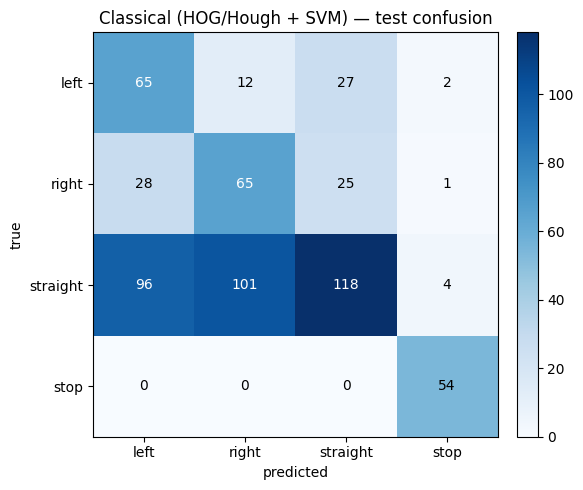

In [6]:
y_pred = clf.predict(X_te)
acc = accuracy_score(y_te, y_pred); f1  = f1_score(y_te, y_pred, average="macro")
print(f"\nTest accuracy   : {acc:.4f}")
print(f"Test macro F1   : {f1:.4f}")
print("\nClassification report:")
target_names = [ID_CLASS[i] for i in sorted(ID_CLASS)]
print(classification_report(y_te, y_pred, target_names=target_names, digits=3, zero_division=0))

cm = confusion_matrix(y_te, y_pred, labels=list(range(4)))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(target_names); ax.set_yticklabels(target_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Classical (HOG/Hough + SVM) — test confusion")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane02_confusion.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Save results manifest

In [7]:
results = {
    "name": "classical_hough_svm",
    "accuracy": float(acc),
    "f1_macro": float(f1),
    "best_C": float(grid.best_params_["svc__estimator__C"]),
    "cv_f1_macro": float(grid.best_score_),
    "n_params": int(np.prod(getattr(clf.named_steps["svc"], "coef_", np.array([])).shape) +
                    np.prod(getattr(clf.named_steps["svc"], "intercept_", np.array([])).shape)),
    "confusion": cm.tolist(),
    "class_names": target_names,
}
with open(ROOT / "artifacts" / "lane02_classical_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "name": "classical_hough_svm",
  "accuracy": 0.5050167224080268,
  "f1_macro": 0.5750341063767017,
  "best_C": 10.0,
  "cv_f1_macro": 0.5101402660194675,
  "n_params": 0,
  "confusion": [
    [
      65,
      12,
      27,
      2
    ],
    [
      28,
      65,
      25,
      1
    ],
    [
      96,
      101,
      118,
      4
    ],
    [
      0,
      0,
      0,
      54
    ]
  ],
  "class_names": [
    "left",
    "right",
    "straight",
    "stop"
  ]
}


## Summary

The classical pipeline gives a fast, transparent baseline for the 4-class direction problem. The dominant failure mode is mistaking gentle curves for straight (small `|a|` after our curvature threshold), and the synthesized `stop` class is trivially separable when the ROI is zeroed — which validates the choice of features but does not certify performance on real "no road visible" scenes.